In [1]:
! pip install pandas scikit-learn seaborn matplotlib scipy

# Package used

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score, max_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer

sys.path.append(os.path.abspath('../../'))

base_dir = os.getcwd()
for _ in range(6):
    if os.path.exists(os.path.join(base_dir, 'app', 'database.py')):
        if base_dir not in sys.path:
            sys.path.append(base_dir)
        break
    base_dir = os.path.dirname(base_dir)
from app.database import get_db
from app.services import resultado
from app.core.pagination import PaginationParams


# Function Helpers

In [3]:
# Function to calculate regression metrics

def calculate_metrics(y_true, y_pred):
    """Calculate regression metrics.

    Args:
        y_true (array-like): True target values.
        y_pred (array-like): Predicted target values.

    Returns:
        tuple: A tuple containing a dictionary of metrics and an array of residuals.
    """
    residuals = y_true - y_pred
    metrics = {
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'medae': np.median(np.abs(residuals)),
        'evs': explained_variance_score(y_true, y_pred),
        'max_error': max_error(y_true, y_pred),
        'mape': mean_absolute_percentage_error(y_true, y_pred),
        'pearson': pearsonr(y_true, y_pred)[0]
    }
    return metrics, residuals

# Function to plot ROC curve

def plot_roc_curve(y_test, residuals):
    umbral = np.median(y_test)
    y_test_bin = (y_test >= umbral).astype(int)
    print(f"Modelo ({residuals['model_class']}):")
    y_score = residuals['y_pred']
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve - Modelo ({residuals['model_class']})")
    plt.legend(loc="lower right")
    plt.show()
    
# Functions to plot residuals
def plot_histograma_residuos(residuals):
    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=50, color='skyblue', edgecolor='black')
    plt.title('Histograma de errores residuales')
    plt.xlabel('Error (valor real - predicción)')
    plt.ylabel('Frecuencia')
    plt.show()

# Function to plot residuals vs. predicted values
def plot_dispersion_residuos(y_pred, residuals):
    plt.figure(figsize=(8, 4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicción (y_pred)')
    plt.ylabel('Error residual (real - predicción)')
    plt.title('Dispersión de residuos vs. predicción')
    plt.show()

# Function to plot boxplot of absolute errors
def plot_boxplot_errores_abs(residuals):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=np.abs(residuals))
    plt.title('Boxplot de errores absolutos')
    plt.xlabel('Error absoluto |real - predicción|')
    plt.show()

In [4]:
# Function to train and evaluate the classic machine learning models

def train_and_evaluate_models(model_class, X_train, X_test, y_train, y_test, **kwargs):
    """Train and evaluate a machine learning model.

    Args:
        model_class (_type_): The class of the model to be trained.
        X_train (_type_): Training features.
        X_test (_type_): Testing features.
        y_train (_type_): Training labels.
        y_test (_type_): Testing labels.

    Returns:
        tuple: A tuple containing the trained model and the predictions on the test set.
    """
    model = model_class(**kwargs)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, y_pred

# function to execute train with the classic machine learning models and evaluate the results
def execute_training_models(X_train, X_test, y_train, y_test, modelos_param_grid):
    """Execute training and evaluation of classic machine learning models.

    Args:
        X_train (_type_): Training features.
        X_test (_type_): Testing features.
        y_train (_type_): Training labels.
        y_test (_type_): Testing labels.
        modelos_param_grid (_type_): List of tuples containing model classes and their corresponding parameter grids.

    Returns:
        tuple: A tuple containing the list of results and the list of trained models.
    """
    resultados = []
    modelos = []
    for i, (model_class, params) in enumerate(modelos_param_grid):
        print(f"\nEntrenando modelo clásico {i+1}: {model_class.__name__} con params: {params}")
        model, y_pred = train_and_evaluate_models(model_class, X_train, X_test, y_train, y_test, **params)
        metrics, residuals = calculate_metrics(y_test, y_pred)
        resultados.append({'model_class': model_class.__name__, 'params': params, 'metrics': metrics, 'residuals': residuals, 'y_pred': y_pred})
        modelos.append(model)
    return resultados, modelos

In [5]:
# Function to train and evaluate the model neuronal network

def train_evaluate_mlp(X_train, X_test, y_train, y_test, 
                        hidden_layer_sizes=(16,), activation='relu', solver='adam',
                        learning_rate='adaptive', learning_rate_init=0.001, max_iter=1000, 
                        random_state=42, validation_fraction=0.1, n_iter_no_change=20, verbose=False):
    """
    Train and evaluate a Multi-layer Perceptron regressor.
    Args:
        X_train: Training features.
        X_test: Testing features.
        y_train: Training labels.
        y_test: Testing labels.
        hidden_layer_sizes: The ith element represents the number of neurons in the ith hidden layer.
        activation: Activation function for the hidden layer.
        solver: The solver for weight optimization.
        learning_rate: Learning rate schedule for weight updates.
        learning_rate_init: The initial learning rate used. It controls the step-size in updating the weights.
        max_iter: Maximum number of iterations. The solver iterates until convergence or this number of iterations.
        random_state: Determines random number generation for weights and bias initialization, train-test split, and batch sampling when solver='sgd' or 'adam'.
        validation_fraction: The proportion of training data to set aside as validation set for early stopping.
        n_iter_no_change: Maximum number of epochs to not meet tol improvement to wait before early stopping.
        verbose: Whether to print progress messages to stdout.
    """
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        learning_rate=learning_rate,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=random_state,
        validation_fraction=validation_fraction,
        n_iter_no_change=n_iter_no_change,
        verbose=verbose
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics, residuals = calculate_metrics(y_test, y_pred)
    return model, y_pred, metrics, residuals

# Function to run experiments with different hyperparameters and save models

def run_experiments(X_train, X_test, y_train, y_test, param_grid):
    results = []
    models = []
    for i, params in enumerate(param_grid):
        print(f"\nEntrenando modelo {i+1} con params: {params}")
        model, y_pred, metrics, residuals = train_evaluate_mlp(
            X_train, X_test, y_train, y_test,
            hidden_layer_sizes=params.get('hidden_layer_sizes', (16,)),
            activation=params.get('activation', 'relu'),
            solver=params.get('solver', 'adam'),
            learning_rate=params.get('learning_rate', 'adaptive'),
            learning_rate_init=params.get('learning_rate_init', 0.001),
            max_iter=params.get('max_iter', 1000),
            random_state=params.get('random_state', 42),
            validation_fraction=params.get('validation_fraction', 0.1),
            n_iter_no_change=params.get('n_iter_no_change', 20),
            verbose=False
        )
        results.append({'model_class': f'MLPRegressor{i+1}', 'params': params, 'metrics': metrics, 'residuals': residuals, 'y_pred': y_pred})
        models.append(model)
    return results, models

In [6]:
# Function to analyze results and generate visualizations

def analized_results(residuals, y_test):
    for i, res in enumerate(residuals):
        print(f"\nModelo {i+1} - Hiperparámetros: {res['params']}")
        print("Métricas:")
        for k, v in res['metrics'].items():
            print(f"  {k}: {v:.4f}")
        plot_histograma_residuos(res['residuals'])
        plot_dispersion_residuos(res['y_pred'], res['residuals'])
        plot_boxplot_errores_abs(res['residuals'])
        plot_roc_curve(y_test, res)

# Function to compare models and display results in a table

def comparative_table(residuals):
    filas = []
    for i, res in enumerate(residuals):
        fila = {'Modelo': i+1}
        fila.update(res['params'])
        fila.update(res['metrics'])
        filas.append(fila)
    df_resultados = pd.DataFrame(filas)
    display(df_resultados.sort_values('r2', ascending=False))

# Upload Data

In [7]:
def upload_data():
    # Connect to the database and load data with pagination
    db = next(get_db())

    # Get all data using pagination
    print("Loading data from the database...")
    print("This may take a few minutes...\n")

    all_resultados = []
    page = 1
    page_size = 100  # Maximum allowed
    total_records = 0

    while True:
        pagination = PaginationParams(page=page, page_size=page_size)
        resultados_batch, total = resultado.get_resultados(db, pagination)
        
        if page == 1:
            total_records = total
            print(f"Total records in DB: {total_records}")
            print(f"Loading in batches of {page_size}...\n")
        
        all_resultados.extend(resultados_batch)
        
        print(f"Page {page}: {len(resultados_batch)} records loaded. Total accumulated: {len(all_resultados)}/{total_records}", end='\r')
        
        # If we got fewer records than the page size, we've reached the end
        if len(resultados_batch) < page_size:
            break
        
        page += 1
        time.sleep(0.1)  # Small pause to avoid overloading the DB

    print(f"\n\n✓ Data loaded successfully")

    # Convert to DataFrame
    df = pd.DataFrame(all_resultados)

    print(f"\nTotal records loaded: {len(df)}")
    print(f"Total in database: {total_records}")
    print(f"\nAvailable columns ({len(df.columns)} columns):")
    for idx, col in enumerate(df.columns, 1):
        print(f"  {idx}. {col}")
    return df

In [8]:
df = upload_data()

Loading data from the database...
This may take a few minutes...

Total records in DB: 15376
Loading in batches of 100...

Page 154: 76 records loaded. Total accumulated: 15376/153766

✓ Data loaded successfully

Total records loaded: 15376
Total in database: 15376

Available columns (38 columns):
  1. resultado_Color_Aparente
  2. diagnostico_Color_Aparente
  3. resultado_Turbiedad
  4. diagnostico_Turbiedad
  5. resultado_Ph
  6. diagnostico_Ph
  7. resultado_Cloro_Residual_Libre
  8. diagnostico_Cloro_Residual_Libre
  9. resultado_Alcalinidad_Total
  10. diagnostico_Alcalinidad_Total
  11. resultado_Aluminio
  12. diagnostico_Aluminio
  13. resultado_Cloruros
  14. diagnostico_Cloruros
  15. resultado_COT
  16. diagnostico_COT
  17. resultado_Dureza_Total
  18. diagnostico_Dureza_Total
  19. resultado_Fosfatos
  20. diagnostico_Fosfatos
  21. resultado_Manganeso
  22. diagnostico_Manganeso
  23. resultado_Nitratos
  24. diagnostico_Nitratos
  25. resultado_Nitritos
  26. diagnostico

# Explore DataFrame

In [9]:
# print the first few rows of the dataframe to verify the data was loaded correctly
print("\nFirst 5 rows of the loaded data:")
display(df.head())

print("\n DataFrame information:")
df.info()

print("\n\n✓ DataFrame description:")
display(df.describe())


First 5 rows of the loaded data:


,resultado_Color_Aparente,diagnostico_Color_Aparente,resultado_Turbiedad,diagnostico_Turbiedad,resultado_Ph,diagnostico_Ph,resultado_Cloro_Residual_Libre,diagnostico_Cloro_Residual_Libre,resultado_Alcalinidad_Total,diagnostico_Alcalinidad_Total,...,resultado_Coliformes_Totales,diagnostico_Coliformes_Totales,resultado_E_Coli,diagnostico_E_Coli,resultado_Floruros,diagnostico_Floruros,resultado_Hierro_Total,diagnostico_Hierro_Total,IRCA,nivel_Riesgo
0,5.00,Aceptable,None,None,7.00,Aceptable,None,None,20.00,Aceptable,...,2419.6000000000,No aceptable,105.0000000000,No aceptable,0.50,Aceptable,0.04,Aceptable,73.39,ALTO
1,5.00,Aceptable,0.50,Aceptable,7.00,Aceptable,None,None,20.00,Aceptable,...,1553.1000000000,No aceptable,117.8000000000,No aceptable,0.50,Aceptable,0.03,Aceptable,57.55,ALTO
2,5.00,Aceptable,0.60,Aceptable,7.00,Aceptable,0.50,Aceptable,20.00,Aceptable,...,2419.6000000000,No aceptable,105.0000000000,No aceptable,0.50,Aceptable,0.04,Aceptable,57.55,ALTO
3,5.00,Aceptable,0.50,Aceptable,7.00,Aceptable,0.50,Aceptable,20.00,Aceptable,...,None,None,0E-10,Aceptable,None,None,0.01,Aceptable,100.00,INVIABLE SANITARIAMENTE
4,5.00,Aceptable,0.50,Aceptable,7.00,Aceptable,0.50,Aceptable,20.00,Aceptable,...,0E-10,Aceptable,0E-10,Aceptable,None,None,0.01,Aceptable,0.00,SIN RIESGO



 DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15376 entries, 0 to 15375
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   resultado_Color_Aparente          14210 non-null  object
 1   diagnostico_Color_Aparente        14210 non-null  object
 2   resultado_Turbiedad               14968 non-null  object
 3   diagnostico_Turbiedad             14968 non-null  object
 4   resultado_Ph                      15289 non-null  object
 5   diagnostico_Ph                    15289 non-null  object
 6   resultado_Cloro_Residual_Libre    9019 non-null   object
 7   diagnostico_Cloro_Residual_Libre  9019 non-null   object
 8   resultado_Alcalinidad_Total       4238 non-null   object
 9   diagnostico_Alcalinidad_Total     4238 non-null   object
 10  resultado_Aluminio                1199 non-null   object
 11  diagnostico_Aluminio              1199 non-null   objec

,resultado_Color_Aparente,diagnostico_Color_Aparente,resultado_Turbiedad,diagnostico_Turbiedad,resultado_Ph,diagnostico_Ph,resultado_Cloro_Residual_Libre,diagnostico_Cloro_Residual_Libre,resultado_Alcalinidad_Total,diagnostico_Alcalinidad_Total,...,resultado_Coliformes_Totales,diagnostico_Coliformes_Totales,resultado_E_Coli,diagnostico_E_Coli,resultado_Floruros,diagnostico_Floruros,resultado_Hierro_Total,diagnostico_Hierro_Total,IRCA,nivel_Riesgo
count,14210,14210,14968,14968,15289,15289,9019,9019,4238,4238,...,15343,15343,15300,15300,1230,1230,3830,3830,15376,15376
unique,24,2,137,2,136,2,230,2,177,2,...,590,2,667,2,7,2,105,2,531,5
top,5.00,Aceptable,0.50,Aceptable,7.00,Aceptable,0.00,Aceptable,20.00,Aceptable,...,0E-10,No aceptable,0E-10,No aceptable,0.50,Aceptable,0.06,Aceptable,0.00,ALTO
freq,8221,11607,3883,11146,3758,14784,1994,5952,1006,4222,...,5333,10010,7450,7850,1223,1226,683,3025,3878,6344


# Clear and prepared DataFrame

In [10]:
# Check for missing values and decide on a strategy (e.g., drop columns with too many nulls, fill others)
umbral_eliminar = 70  # remove columns with >70% nulls
null_porcentaje = df.isnull().mean() * 100
remove_columns = null_porcentaje[null_porcentaje > umbral_eliminar].index.tolist()
df = df.drop(columns=remove_columns)

In [11]:
print("\n DataFrame information after removing columns with >70% nulls:")
df.info()


 DataFrame information after removing columns with >70% nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15376 entries, 0 to 15375
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   resultado_Color_Aparente          14210 non-null  object
 1   diagnostico_Color_Aparente        14210 non-null  object
 2   resultado_Turbiedad               14968 non-null  object
 3   diagnostico_Turbiedad             14968 non-null  object
 4   resultado_Ph                      15289 non-null  object
 5   diagnostico_Ph                    15289 non-null  object
 6   resultado_Cloro_Residual_Libre    9019 non-null   object
 7   diagnostico_Cloro_Residual_Libre  9019 non-null   object
 8   resultado_Cloruros                5454 non-null   object
 9   diagnostico_Cloruros              5454 non-null   object
 10  resultado_Nitritos                6327 non-null   object
 11  diagnostico_Nitr

In [12]:
# Selected and cleaned numerical and categorical columns
numerical_columns = [col for col in df.columns if 'resultado' in col.lower()]
categorical_columns = [col for col in df.columns if 'diagnostico' in col.lower()]
df.drop(columns=categorical_columns, inplace=True)
df.drop(columns=['nivel_Riesgo'], inplace=True)
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['IRCA'] = pd.to_numeric(df['IRCA'], errors='coerce')

In [13]:
# Imputer for numerical columns
imputer_num = SimpleImputer(strategy="mean")
df[numerical_columns] = imputer_num.fit_transform(df[numerical_columns])

In [14]:
# Trim the dataset in caracteristics and target
X = df.drop(columns=['IRCA'], axis=1)
y = df['IRCA']

In [15]:
# normalized sclar DataFrame
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

print("\nDatos normalizados:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nDatos normalizados info:")
print("X mean:", np.mean(X, axis=0))
print("X std:", np.std(X, axis=0))
print("y mean:", np.mean(y))
print("y std:", np.std(y))


Datos normalizados:
X shape: (15376, 8)
y shape: (15376,)

Datos normalizados info:
X mean: [ 6.65440647e-17 -9.61192046e-17  1.19964161e-15 -1.40481914e-16
  2.95751399e-17 -9.24223121e-18  3.32720324e-17  2.40298012e-17]
X std: [1. 1. 1. 1. 1. 1. 1. 1.]
y mean: 1.848446242872269e-18
y std: 0.9999999999999999


In [16]:
# Trim in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Experiments Models Classic

In [17]:

# Define the parameter grid for classic machine learning models
param_grid_regresores = [
    (LinearRegression, {}), # Linear Regression doesn't have hyperparameters to tune in this context
    (RandomForestRegressor, {'n_estimators': 100, 'random_state': 42}), # Random Forest with 100 trees and fixed random state for reproducibility
    (DecisionTreeRegressor, {'max_depth': 5, 'random_state': 42}), # Decision Tree with max depth of 5 and fixed random state for reproducibility
    (SVR, {'kernel': 'rbf', 'C': 1.0}) # Support Vector Regressor with RBF kernel and C=1.0
]


Entrenando modelo clásico 1: LinearRegression con params: {}



Entrenando modelo clásico 2: RandomForestRegressor con params: {'n_estimators': 100, 'random_state': 42}

Entrenando modelo clásico 3: DecisionTreeRegressor con params: {'max_depth': 5, 'random_state': 42}

Entrenando modelo clásico 4: SVR con params: {'kernel': 'rbf', 'C': 1.0}

Modelo 1 - Hiperparámetros: {}
Métricas:
  mse: 0.4281
  rmse: 0.6543
  r2: 0.5773
  mae: 0.5424
  medae: 0.5568
  evs: 0.5773
  max_error: 2.2132
  mape: 0.7673
  pearson: 0.7633


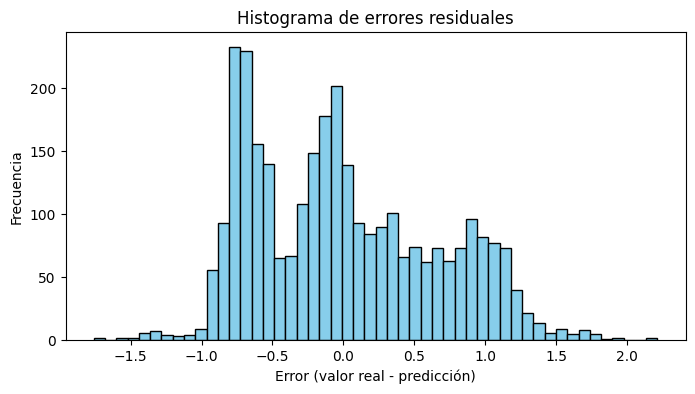

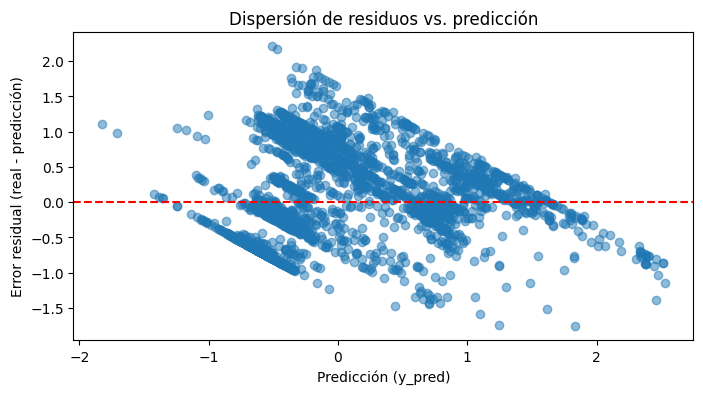

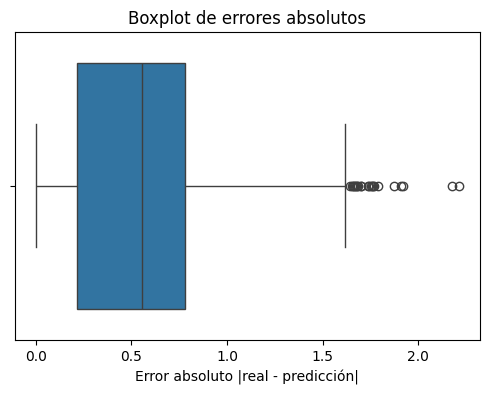

Modelo (LinearRegression):


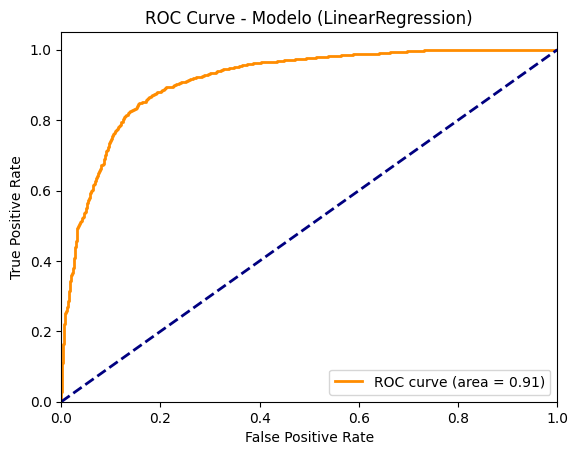


Modelo 2 - Hiperparámetros: {'n_estimators': 100, 'random_state': 42}
Métricas:
  mse: 0.0087
  rmse: 0.0932
  r2: 0.9914
  mae: 0.0253
  medae: 0.0045
  evs: 0.9914
  max_error: 2.3783
  mape: 0.0658
  pearson: 0.9957


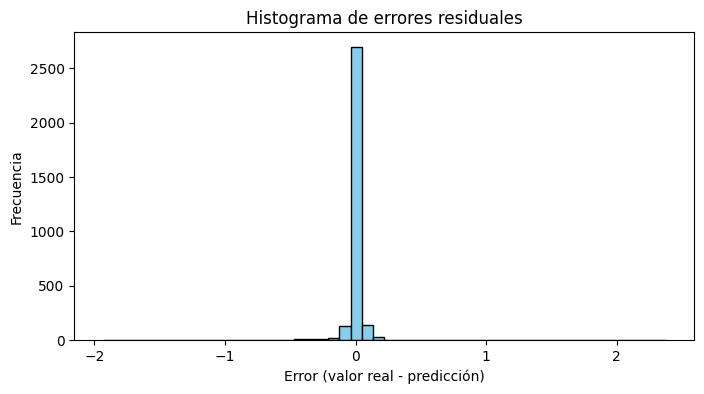

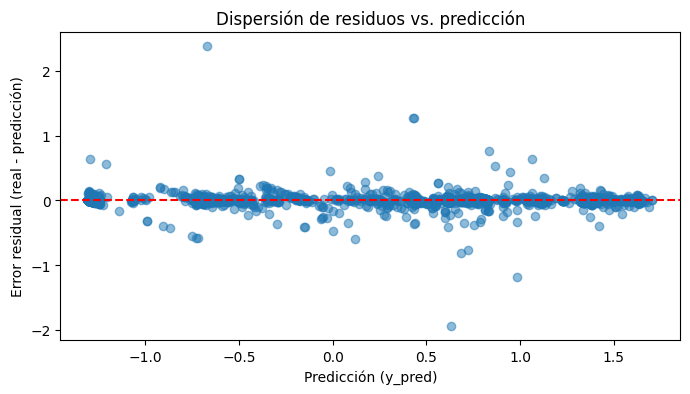

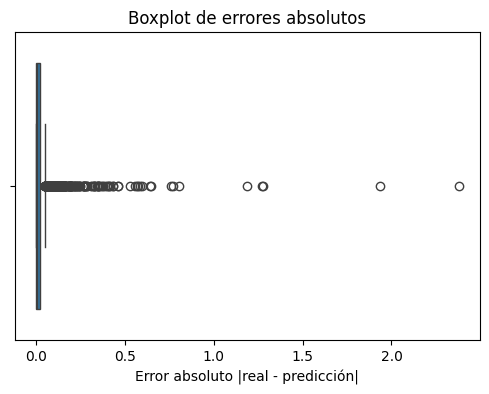

Modelo (RandomForestRegressor):


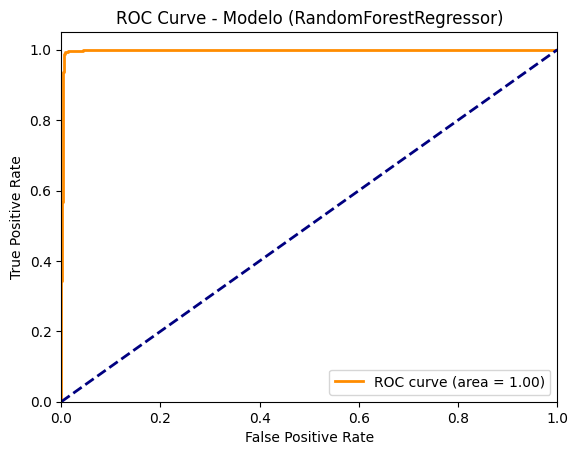


Modelo 3 - Hiperparámetros: {'max_depth': 5, 'random_state': 42}
Métricas:
  mse: 0.0202
  rmse: 0.1422
  r2: 0.9800
  mae: 0.0803
  medae: 0.0574
  evs: 0.9800
  max_error: 2.3475
  mape: 0.1806
  pearson: 0.9900


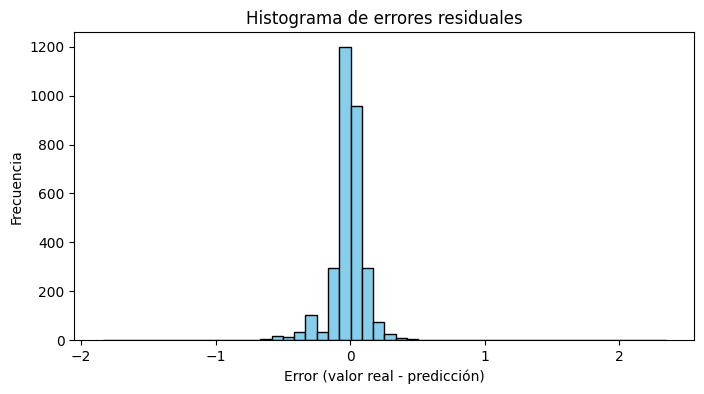

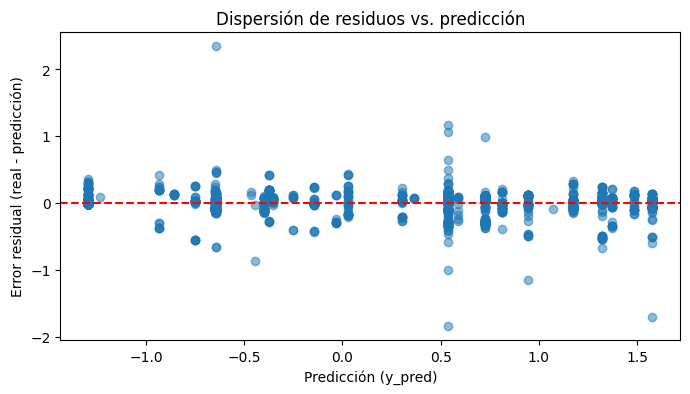

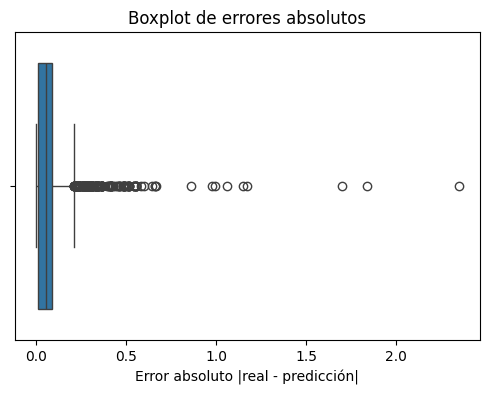

Modelo (DecisionTreeRegressor):


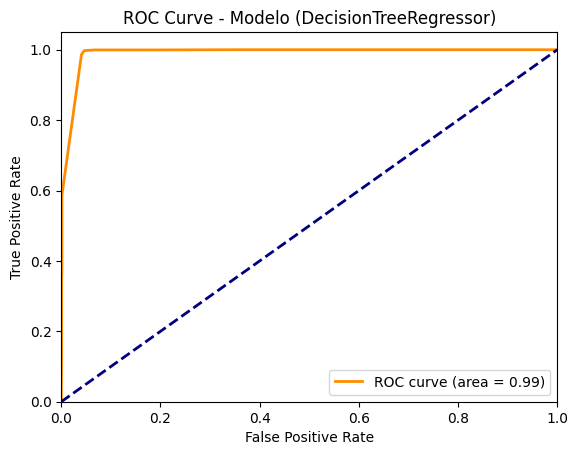


Modelo 4 - Hiperparámetros: {'kernel': 'rbf', 'C': 1.0}
Métricas:
  mse: 0.2134
  rmse: 0.4620
  r2: 0.7893
  mae: 0.3007
  medae: 0.1688
  evs: 0.7938
  max_error: 2.2858
  mape: 0.5955
  pearson: 0.8917


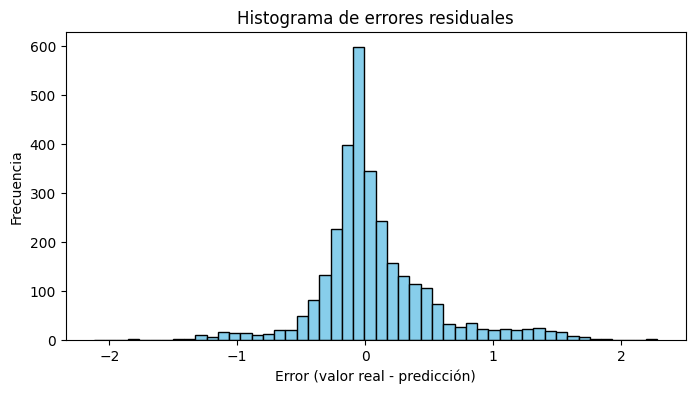

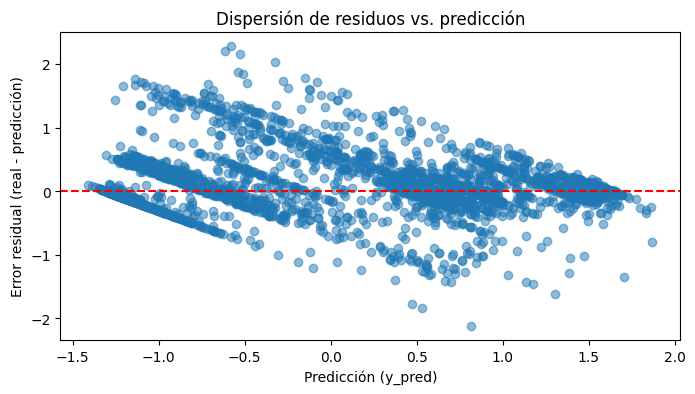

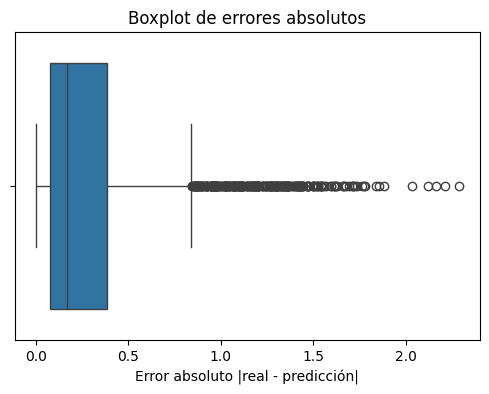

Modelo (SVR):


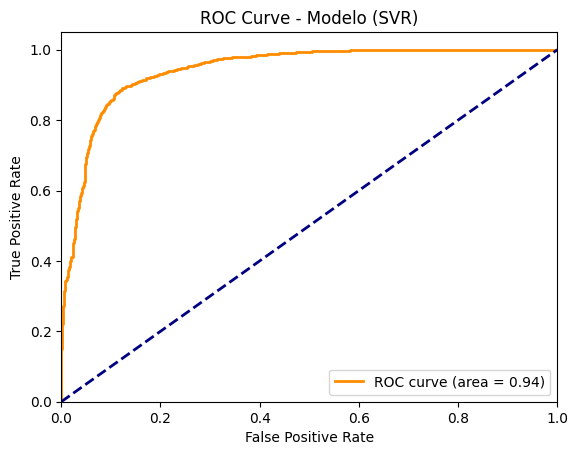

,Modelo,mse,rmse,r2,mae,medae,evs,max_error,mape,pearson,n_estimators,random_state,max_depth,kernel,C
1,2,0.008692,0.093232,0.991418,0.025278,0.004531,0.991419,2.378339,0.065763,0.995701,100.0,42.0,NaN,NaN,NaN
2,3,0.020229,0.142227,0.980029,0.080264,0.057400,0.980030,2.347453,0.180576,0.989965,NaN,42.0,5.0,NaN,NaN
3,4,0.213398,0.461950,0.789320,0.300673,0.168754,0.793759,2.285754,0.595460,0.891679,NaN,NaN,NaN,rbf,1.0
0,1,0.428144,0.654328,0.577308,0.542375,0.556815,0.577308,2.213160,0.767301,0.763289,NaN,NaN,NaN,NaN,NaN


In [18]:
residuals_regress, models_regress = execute_training_models(
    X_train, X_test, y_train, y_test, param_grid_regresores
)

analized_results(residuals_regress, y_test)


comparative_table(residuals_regress)


# Experiments Model Neuronal networks

In [19]:
param_grid = [
    {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.01},
]


Entrenando modelo 1 con params: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 2 con params: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 3 con params: {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 4 con params: {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001}

Entrenando modelo 5 con params: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.01}

Modelo 1 - Hiperparámetros: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.0922
  rmse: 0.3036
  r2: 0.9090
  mae: 0.2141
  medae: 0.1471
  evs: 0.9091
  max_error: 2.0623
  mape: 0.4690
  pearson: 0.9543


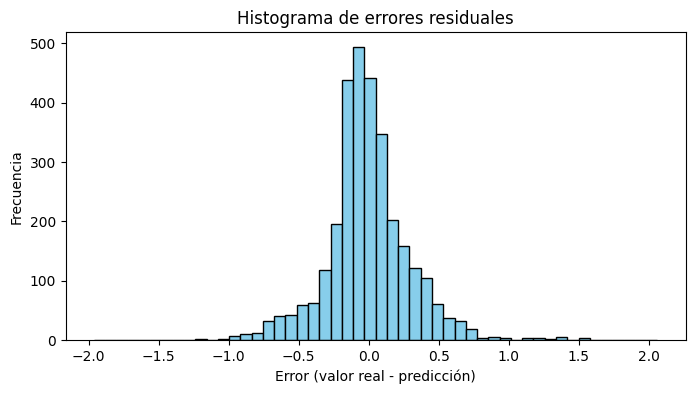

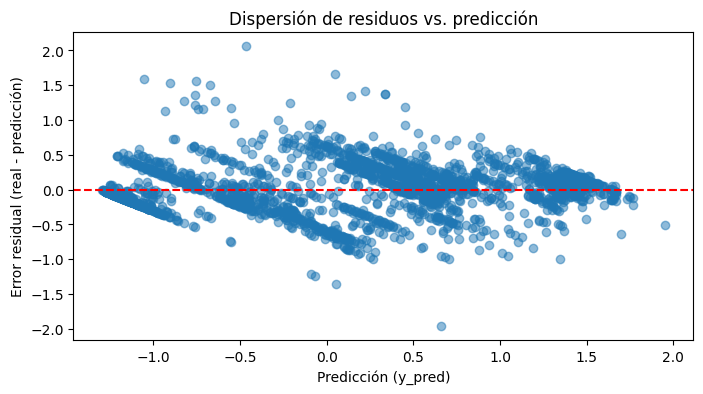

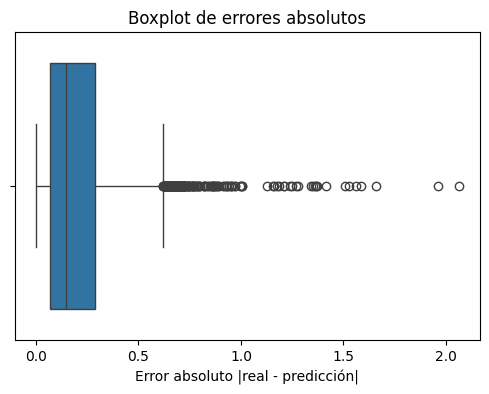

Modelo (MLPRegressor1):


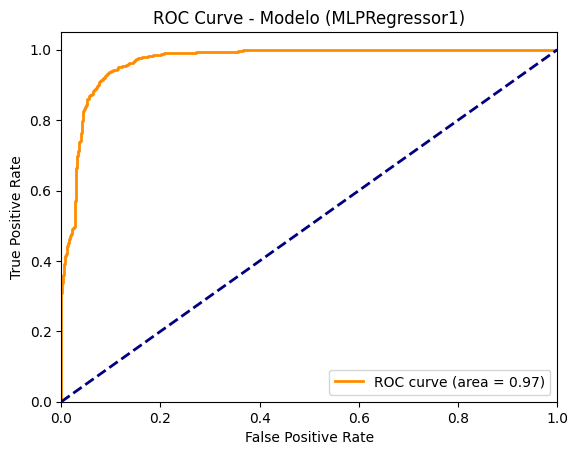


Modelo 2 - Hiperparámetros: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.0765
  rmse: 0.2766
  r2: 0.9245
  mae: 0.1808
  medae: 0.0985
  evs: 0.9245
  max_error: 2.2097
  mape: 0.4010
  pearson: 0.9616


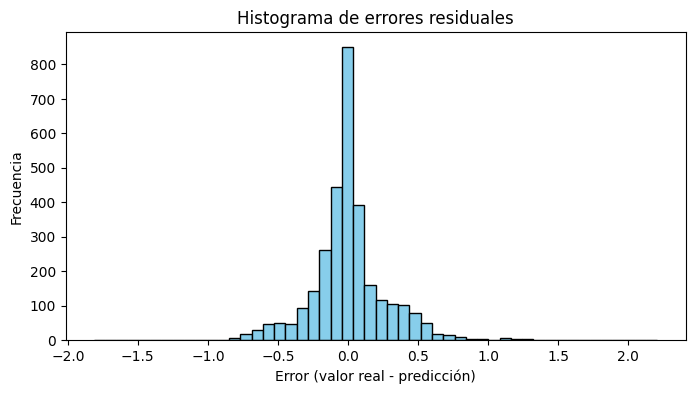

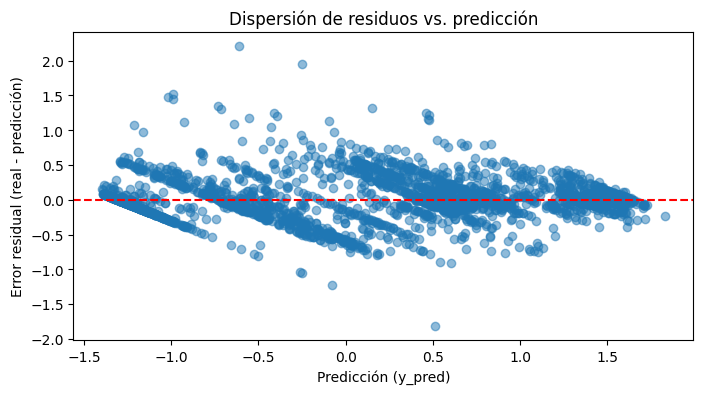

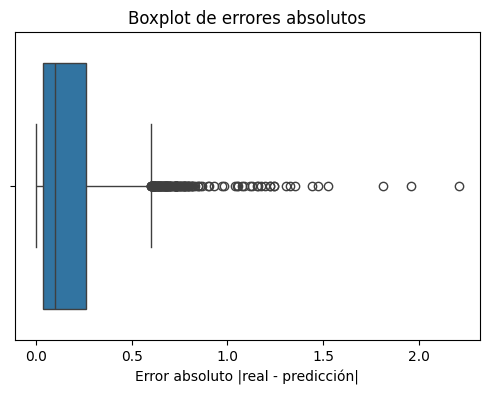

Modelo (MLPRegressor2):


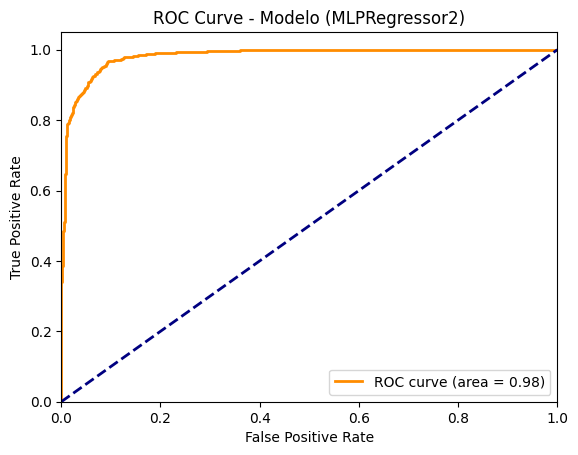


Modelo 3 - Hiperparámetros: {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.0432
  rmse: 0.2078
  r2: 0.9574
  mae: 0.1318
  medae: 0.0773
  evs: 0.9577
  max_error: 2.3279
  mape: 0.2820
  pearson: 0.9786


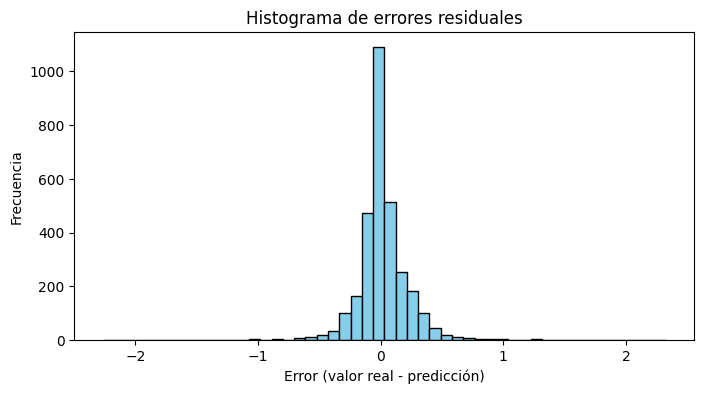

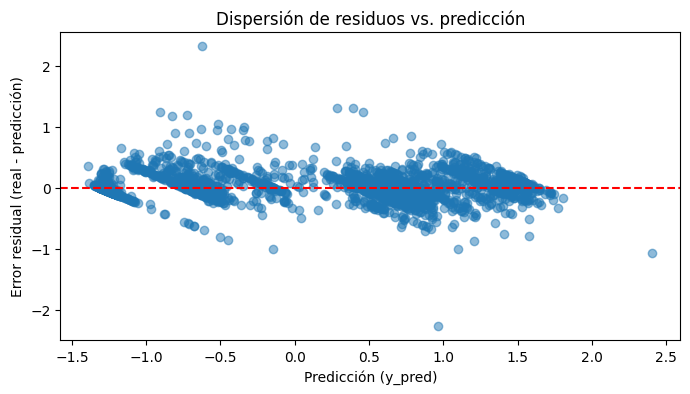

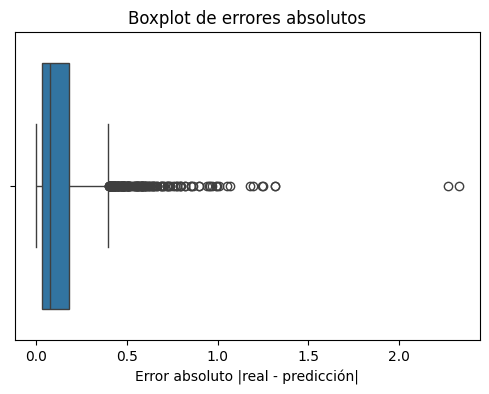

Modelo (MLPRegressor3):


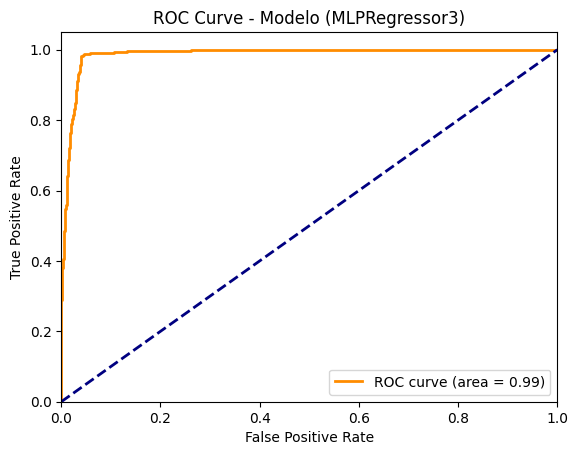


Modelo 4 - Hiperparámetros: {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.1159
  rmse: 0.3405
  r2: 0.8856
  mae: 0.2271
  medae: 0.1449
  evs: 0.8856
  max_error: 2.4465
  mape: 0.4781
  pearson: 0.9412


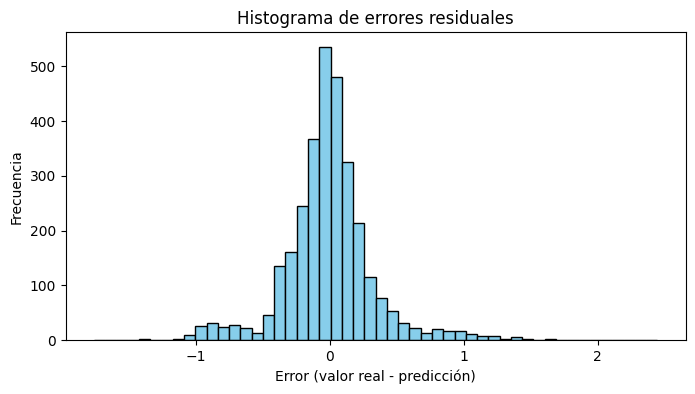

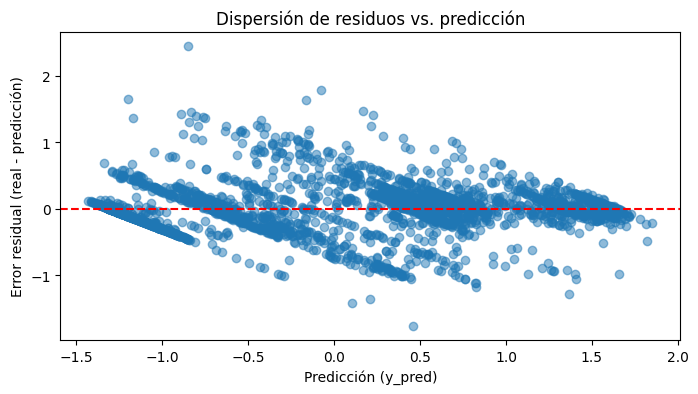

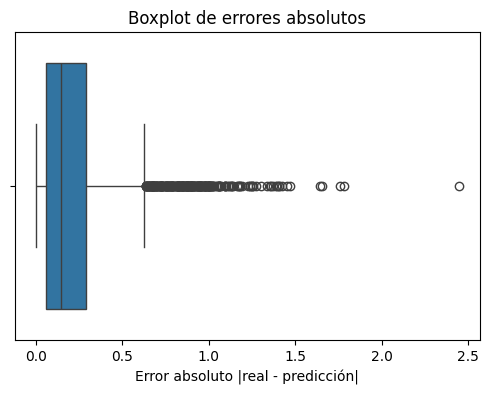

Modelo (MLPRegressor4):


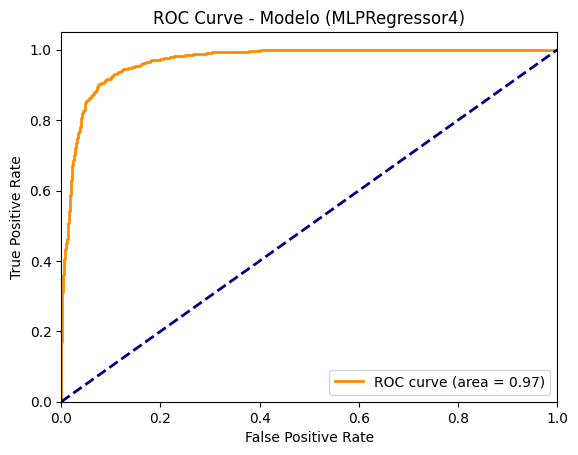


Modelo 5 - Hiperparámetros: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.01}
Métricas:
  mse: 0.0600
  rmse: 0.2450
  r2: 0.9408
  mae: 0.1730
  medae: 0.1274
  evs: 0.9408
  max_error: 2.2619
  mape: 0.3295
  pearson: 0.9708


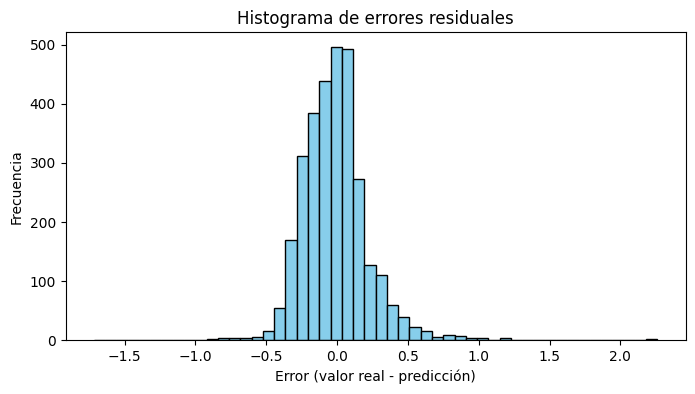

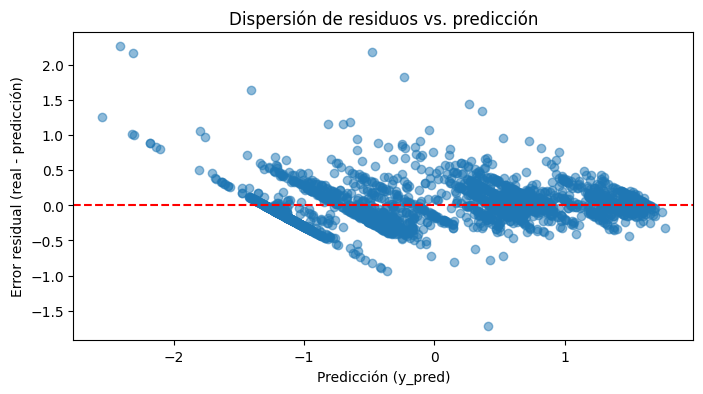

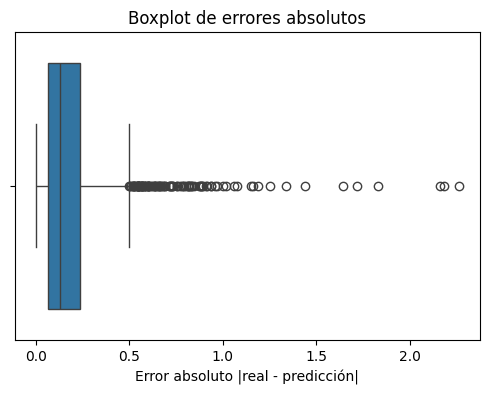

Modelo (MLPRegressor5):


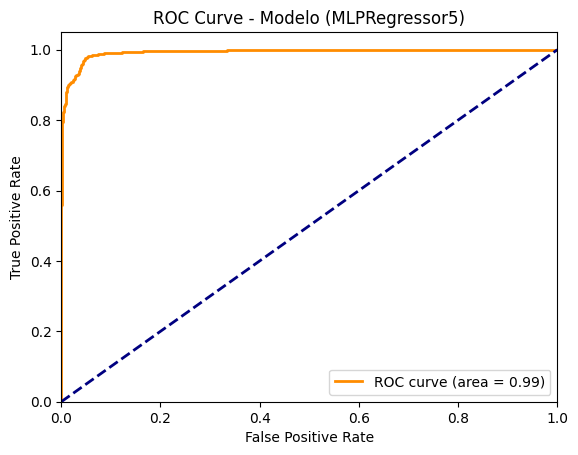

,Modelo,hidden_layer_sizes,activation,learning_rate_init,mse,rmse,r2,mae,medae,evs,max_error,mape,pearson
2,3,"(16, 8)",relu,0.001,0.043176,0.207788,0.957374,0.131785,0.077299,0.957710,2.327867,0.282016,0.978634
4,5,"(16,)",relu,0.010,0.060008,0.244965,0.940756,0.173038,0.127386,0.940841,2.261900,0.329508,0.970845
1,2,"(32,)",relu,0.001,0.076494,0.276576,0.924480,0.180763,0.098503,0.924542,2.209727,0.400980,0.961569
0,1,"(16,)",relu,0.001,0.092188,0.303625,0.908986,0.214068,0.147083,0.909050,2.062339,0.469047,0.954288
3,4,"(16,)",tanh,0.001,0.115913,0.340459,0.885564,0.227115,0.144872,0.885602,2.446483,0.478093,0.941181


In [20]:
residuals, models = run_experiments(X_train, X_test, y_train, y_test, param_grid)

analized_results(residuals, y_test)

comparative_table(residuals) 

# Save Best Model

In [24]:

# Reconstruir scalers explícitos (X e y por separado)
X_raw = df.drop(columns=['IRCA']).values
y_raw = df['IRCA'].values

scaler_X = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw.reshape(-1, 1))

feature_names = list(df.drop(columns=['IRCA']).columns)

# Seleccionar SIEMPRE el mejor modelo MLP por R²
mejor_idx_mlp = max(
    range(len(residuals)),
    key=lambda i: residuals[i]['metrics']['r2']
)
mejor_modelo_final = models[mejor_idx_mlp]
mejor_resultado_final = residuals[mejor_idx_mlp]

# Referencia informativa: mejor modelo clásico (solo para comparación)
mejor_idx_clasico = max(
    range(len(residuals_regress)),
    key=lambda i: residuals_regress[i]['metrics']['r2']
)
mejor_resultado_clasico = residuals_regress[mejor_idx_clasico]

print(f"Modelo seleccionado : {type(mejor_modelo_final).__name__}")
print(f"Parámetros                      : {mejor_resultado_final.get('params', {})}")
print(f"R² MLP guardado                 : {mejor_resultado_final['metrics']['r2']:.4f}")
print(f"R² mejor clásico {mejor_resultado_clasico['model_class']}   : {mejor_resultado_clasico['metrics']['r2']:.4f}")
print(f"RMSE                            : {mejor_resultado_final['metrics']['rmse']:.4f}")
print(f"Características                 : {feature_names}")

# Ensamblar artefacto
artefacto = {
    'modelo': mejor_modelo_final,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_names': feature_names,
    'metadata': {
        'model_class': type(mejor_modelo_final).__name__,
        'params': mejor_resultado_final.get('params', {}),
        'metricas': {k: float(v) for k, v in mejor_resultado_final['metrics'].items()},
    },
}

print("\n✓ Artefacto ensamblado con modelo, scalers, características y metadata.")

print(artefacto['metadata'])

# Guardar en el mismo directorio que este notebook
ruta_modelo = os.path.join(os.getcwd(), '../../modelo_irca_best.joblib')
joblib.dump(artefacto, ruta_modelo)
print(f"\nModelo guardado en: {ruta_modelo}")

Modelo seleccionado : MLPRegressor
Parámetros                      : {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}
R² MLP guardado                 : 0.9574
R² mejor clásico RandomForestRegressor   : 0.9914
RMSE                            : 0.2078
Características                 : ['resultado_Color_Aparente', 'resultado_Turbiedad', 'resultado_Ph', 'resultado_Cloro_Residual_Libre', 'resultado_Cloruros', 'resultado_Nitritos', 'resultado_Coliformes_Totales', 'resultado_E_Coli']

✓ Artefacto ensamblado con modelo, scalers, características y metadata.
{'model_class': 'MLPRegressor', 'params': {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}, 'metricas': {'mse': 0.04317592338952832, 'rmse': 0.207788169512916, 'r2': 0.9573738940730476, 'mae': 0.13178498736081326, 'medae': 0.07729896386693591, 'evs': 0.9577102021324592, 'max_error': 2.3278670058898934, 'mape': 0.28201602495790995, 'pearson': 0.9786337026115339}}

Modelo guar